# Rep 3. Checkpoint 2. Black Scholes y Volatility surface


### Contexto
El modelo de Black–Scholes asume que la volatilidad es constante para todos los strikes. En la práctica, el mercado no opera bajo ese supuesto — cada opción tiene un precio distinto que implica una volatilidad distinta. La curva que forman esas volatilidades se llama volatility skew, y es una de las señales más directas de cómo el mercado está distribuyendo el riesgo.

### Instrucciones
Usando el código visto en clase, calcula la volatilidad implícita para al menos 10 strikes distintos del vencimiento 2026-04-17, en el rango [S0 × 0.88, S0 × 1.10].

El precio spot y el precio mid de cada opción deben obtenerse dinámicamente — no hardcodear valores.

Con los resultados, construye dentro de tu código:

Una tabla con columnas: Strike | Bid | Ask | Mid | IV (%)
Una gráfica de IV (%) vs. Strike, con una línea vertical en S0 indicando el precio ATM- . plt.plot(strikes, ivs)
### Preguntas
Responde dentro del notebook como celdas de texto (Markdown):

- ¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica eso?
- ¿En qué strike es mínima la IV? ¿Coincide con S0?
- ¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?
- ¿Qué le diría esta curva a alguien que quiere usar Black–Scholes con una sola volatilidad constante?

S0: 648.57 | T: 0.0712 | r: 0.042
 Strike   Bid   Ask    Mid    IV (%)
  575.0  2.49  2.54  2.515 35.135494
  615.0  6.42  6.48  6.450 28.558415
  632.0  9.96 10.05 10.005 26.046459
  641.0 12.56 12.66 12.610 24.703502
  650.0 15.75 15.86 15.805 23.268492
  659.0 18.65 20.95 19.800 21.865739
  668.0 23.48 24.63 24.055 19.431109
  677.0 28.67 31.48 30.075 18.099675
  686.0 36.36 37.64 37.000 16.484551
  695.0 45.00 45.74 45.370 17.144488
  704.0 53.46 54.74 54.100 18.497723
  713.0 61.73 64.49 63.110 20.994441


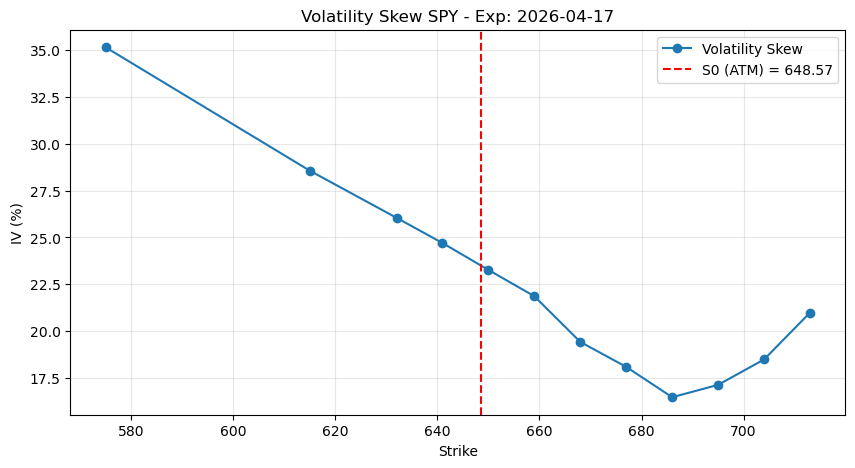

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def bs_price(S, K, r, T, sigma, option="call"):
    if sigma <= 0 or T <= 0:
        if option == "call":
            return max(0.0, S - K*np.exp(-r*T))
        else:
            return max(0.0, K*np.exp(-r*T) - S)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option == "call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_vega(S, K, r, T, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def implied_vol(price_mkt, S, K, r, T, option="call", brent_bounds=(1e-6, 5.0), tol=1e-8, maxiter=100):
    if option == "call":
        lower = max(0.0, S - K*np.exp(-r*T))
        upper = S
    else:
        lower = max(0.0, K*np.exp(-r*T) - S)
        upper = K*np.exp(-r*T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        return np.nan 

    def f(sig):
        return bs_price(S, K, r, T, sig, option) - price_mkt

    a, b = brent_bounds
    try:
        fa, fb = f(a), f(b)
        if fa*fb > 0:
            for b_try in [10.0, 15.0, 25.0, 50.0]:
                fb = f(b_try)
                if fa*fb <= 0:
                    b = b_try
                    break
        return brentq(f, a, b, xtol=tol, maxiter=maxiter)
    except:
        pass

    seed = 0.2
    try:
        iv = newton(lambda s: f(s), seed, fprime=lambda s: bs_vega(S, K, r, T, s), tol=tol, maxiter=maxiter)
        return iv if iv > 0 else np.nan
    except:
        return np.nan


ticker = 'SPY'
tk = yf.Ticker(ticker)
exp = '2026-04-17'
today = date.today()

data = yf.download(ticker, start='2022-01-01', end=today, progress=False)['Close']
S0 = float(data.iloc[-1])
r = 0.042
T = (date.fromisoformat(exp) - today).days / 365

chain = tk.option_chain(exp).puts
mask = (chain['strike'] >= S0 * 0.88) & (chain['strike'] <= S0 * 1.10)
df_subset = chain[mask].copy()

if len(df_subset) > 10:
    indices = np.linspace(0, len(df_subset)-1, 12, dtype=int)
    df_subset = df_subset.iloc[indices]

resultados = []
for i, row in df_subset.iterrows():
    mid = (row['bid'] + row['ask']) / 2
    iv_val = implied_vol(mid, S0, row['strike'], r, T, option="put")
    resultados.append({
        'Strike': row['strike'],
        'Bid': row['bid'],
        'Ask': row['ask'],
        'Mid': mid,
        'IV (%)': iv_val * 100 if not np.isnan(iv_val) else None
    })

df_final = pd.DataFrame(resultados).dropna()


print(f"S0: {S0:.2f} | T: {T:.4f} | r: {r}")
print(df_final.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(df_final['Strike'], df_final['IV (%)'], 'o-', label='Volatility Skew')
plt.axvline(S0, color='red', linestyle='--', label=f'S0 (ATM) = {S0:.2f}')
plt.title(f'Volatility Skew {ticker} - Exp: {exp}')
plt.xlabel('Strike')
plt.ylabel('IV (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Preguntas
- **¿La curva de IV es decreciente, creciente o tiene forma de smile? ¿Qué implica eso?**
        La curva parece seguir una sonrisa; al inicio empieza con valores altos y conforme sube el precio de strike, empieza a bajar, pero luego, hacia los strikes más altos, empezamos a ver una subida otra vez. En otras palabras, el mercado no sigue una distribución normal, el mercado asigna una mayor probabilidad hacia las colas pesadas y el hecho de que hacia la izquierda tengamos la IV más alta nos muestra el miedo que el mercado le tiene a las caídas


- **¿En qué strike es mínima la IV? ¿Coincide con S0?**
        El precio strike con la minima IV, es 686. No coincide con el precio spot.

- **¿Qué estarían comprando los inversores que pagan una IV alta en strikes bajos?**
        Están comprando protección. Pagar una IV del 35% por un strike 575 significa que los inversores tienen miedo a un black swan, están dispuestos a pagar más con tal de estar cubiertos si el mercado se va para abajo. También capaz solo creen que el activo va a bajar, entonces no les importa pagar mucho porque piensan que van a ganar mucho, con la caida a la hora de  hacer short.

- **¿Qué le diría esta curva a alguien que quiere usar Black–Scholes con una sola volatilidad constante?**
        Le mostraría que Black–Scholes no es realista y que muchas veces la volatilidad no es constante, ya que el mercado se rige por muchas otras cosas.